# gradient-boosted tree

In [1]:
import pandas as pd

In [2]:
from dataengineers import Dataset

In [3]:
dataset = Dataset('train')
train, test = dataset.build_train_test()

In [4]:
exclude = ['id', 'target', 'delivery_start']

In [5]:
features = [c for c in train.columns if c not in exclude]

In [6]:
from models import XGB

In [7]:
xg = XGB(features)

In [8]:
xg.fit(train, test)

[0]	validation_0-rmse:152.09925	validation_1-rmse:62.87876
[100]	validation_0-rmse:119.27332	validation_1-rmse:53.46553
[200]	validation_0-rmse:100.68952	validation_1-rmse:49.32961
[300]	validation_0-rmse:88.70899	validation_1-rmse:47.05757
[400]	validation_0-rmse:79.90878	validation_1-rmse:45.53266
[500]	validation_0-rmse:73.31926	validation_1-rmse:44.48206
[600]	validation_0-rmse:67.99144	validation_1-rmse:43.80065
[700]	validation_0-rmse:63.54227	validation_1-rmse:43.25580
[800]	validation_0-rmse:59.95068	validation_1-rmse:43.01127
[900]	validation_0-rmse:56.88678	validation_1-rmse:42.79455
[1000]	validation_0-rmse:54.24962	validation_1-rmse:42.71253
[1047]	validation_0-rmse:53.14750	validation_1-rmse:42.75482


In [9]:
y_vals = xg.predict(test)

/home/matt/repos/nitor-comp/.venv/lib/python3.14/site-packages/xgboost/core.py:751: UserWarning: [16:41:45] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [10]:
from utils import rmse

In [11]:
rmse(test['target'], y_vals)

np.float64(42.701795618094366)

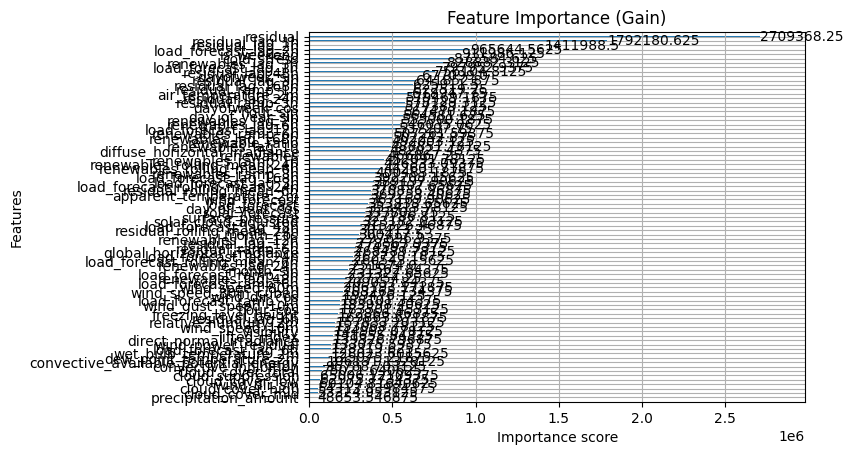

In [25]:
xg.stats(100)

In [26]:
xg.dump_features()

['global_horizontal_irradiance', 'diffuse_horizontal_irradiance', 'direct_normal_irradiance', 'cloud_cover_total', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'precipitation_amount', 'visibility', 'air_temperature_2m', 'apparent_temperature_2m', 'dew_point_temperature_2m', 'wet_bulb_temperature_2m', 'surface_pressure', 'freezing_level_height', 'relative_humidity_2m', 'convective_available_potential_energy', 'lifted_index', 'convective_inhibition', 'wind_speed_80m', 'wind_gust_speed_10m', 'wind_speed_10m', 'solar_forecast', 'wind_forecast', 'load_forecast', 'is_weekend', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'renewables', 'renewable_ratio', 'residual', 'cloud_suppression', 'solar_cloud_adjusted', 'cold_stress', 'heat_stress', 'wind_dir_sin', 'wind_dir_cos', 'wind_speed_80m_cubed', 'wind_power_residual', 'renewables_lag_1h', 'renewables_lag_2h', 'renewables_lag_3h', 'renewables_lag_6h', 'ren

In [13]:
ds2 = Dataset('test')

In [14]:
df_out = ds2.build_main()

In [15]:
y_out = xg.predict(df_out)

In [16]:
df_out['target'] = y_out

In [17]:
df_out.head()

,id,global_horizontal_irradiance,diffuse_horizontal_irradiance,direct_normal_irradiance,cloud_cover_total,cloud_cover_low,cloud_cover_mid,cloud_cover_high,precipitation_amount,visibility,...,load_forecast_lag_12h,load_forecast_lag_24h,load_forecast_lag_48h,load_forecast_lag_168h,load_forecast_rolling_mean_6h,load_forecast_rolling_mean_24h,load_forecast_ramp_1h,load_forecast_ramp_3h,load_forecast_ramp_6h,target
0,133627,0.0,0.0,0.0,100.0,14.0,44.0,100.0,0.0,16600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132.391022
1,133635,0.0,0.0,0.0,100.0,100.0,100.0,88.0,0.0,13800.0,...,NaN,NaN,NaN,NaN,55189.474200,55189.474200,-2203.0271,NaN,NaN,72.691673
2,133643,0.0,0.0,0.0,100.0,70.0,100.0,100.0,0.0,19700.0,...,NaN,NaN,NaN,NaN,54087.960650,54087.960650,-1707.9816,NaN,NaN,135.129364
3,133651,0.0,0.0,0.0,99.0,13.0,99.0,94.0,0.0,16200.0,...,NaN,NaN,NaN,NaN,53151.462267,53151.462267,-893.3085,-4804.3172,NaN,143.377991
4,133659,0.0,0.0,0.0,96.0,0.0,96.0,79.0,0.0,14500.0,...,NaN,NaN,NaN,NaN,52459.885950,52459.885950,-439.4928,-3040.7829,NaN,138.205231


In [18]:
from utils import Submission

In [19]:
submit = Submission(df_out)

In [20]:
submit.process()

,id,target
0,133627,132.391022
2183,133629,63.860535
4366,133630,62.935181
10915,133631,54.773201
6549,133633,51.771744
...,...,...
4365,146774,58.523640
6548,146775,30.475687
13097,146776,32.931999
8731,146777,36.072849


In [21]:
submit.validate()

✅ Validation passed!


In [22]:
submit.dump()